In [ ]:
!pip install transformers datasets seqeval emoji wordninja --quiet

import os, re, json, random, numpy as np, torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
from transformers import BertTokenizerFast, BertForTokenClassification
from datasets import load_dataset
from seqeval.metrics import classification_report
from collections import defaultdict, Counter
import emoji, wordninja, warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

In [ ]:
import urllib.request, json

UPOS_TAGS = ['ADJ','ADP','ADV','AUX','CCONJ','DET','INTJ',
             'NOUN','NUM','PART','PRON','PROPN','PUNCT',
             'SCONJ','SYM','VERB','X']
tag2id = {t: i for i, t in enumerate(UPOS_TAGS)}
id2tag = {i: t for t, i in tag2id.items()}
NUM_LABELS = len(UPOS_TAGS)

def load_conllu(url):
    with urllib.request.urlopen(url) as f:
        content = f.read().decode('utf-8')
    samples, tokens, tags = [], [], []
    for line in content.splitlines():
        line = line.strip()
        if not line or line.startswith('#'):
            if tokens:
                samples.append({'tokens': tokens, 'pos': tags})
                tokens, tags = [], []
        else:
            parts = line.split('\t')
            if len(parts) >= 4 and '-' not in parts[0] and '.' not in parts[0]:
                tokens.append(parts[1])
                tags.append(parts[3] if parts[3] in tag2id else 'X')
    if tokens:
        samples.append({'tokens': tokens, 'pos': tags})
    return samples

# ✅ Correct: branch=dev, filenames=en-ud-tweet-{split}.conllu
BASE = "https://raw.githubusercontent.com/Oneplus/Tweebank/dev"
train_data = load_conllu(f"{BASE}/en-ud-tweet-train.conllu")
dev_data   = load_conllu(f"{BASE}/en-ud-tweet-dev.conllu")
test_data  = load_conllu(f"{BASE}/en-ud-tweet-test.conllu")

print(f"Train: {len(train_data)} | Dev: {len(dev_data)} | Test: {len(test_data)}")
print("Sample tokens:", train_data[0]['tokens'])
print("Sample POS:   ", train_data[0]['pos'])

In [ ]:
EMOJI_MAP = {
    '🔥':'fire_excitement','📉':'market_drop','📈':'market_rise',
    '🚨':'alert_breaking','✅':'confirmed','❌':'denied',
    '🇺🇸':'united_states','🌍':'world','💔':'heartbreak',
    '😂':'laughter','😡':'anger','🎉':'celebration',
    '🙏':'gratitude','💪':'strength','👀':'attention',
    '⚡':'fast_breaking','🤔':'questioning','📢':'announcement',
}

def expand_emoji(tok):
    if tok in EMOJI_MAP: return EMOJI_MAP[tok]
    d = emoji.demojize(tok)
    return d.strip(':').replace('_',' ') if d != tok else tok

def split_hashtag(tok):
    if tok.startswith('#') and len(tok) > 1:
        parts = wordninja.split(tok[1:])
        return parts if parts else [tok[1:]]
    return [tok]

def is_emoji(tok):
    return tok in emoji.EMOJI_DATA or tok in EMOJI_MAP

def preprocess_tweet(tokens, tags, do_hashtag=True, do_emoji=True):
    new_tokens, new_tags = [], []
    for tok, tag in zip(tokens, tags):
        if do_emoji and is_emoji(tok):
            new_tokens.append(expand_emoji(tok))
            new_tags.append(tag)
        elif do_hashtag and tok.startswith('#'):
            parts = split_hashtag(tok)
            new_tokens.extend(parts)
            new_tags.extend(['PROPN'] * len(parts))
        else:
            new_tokens.append(tok)
            new_tags.append(tag)
    return new_tokens, new_tags

print("Preprocessing ready.")
print("Hashtag test:", split_hashtag('#ClimateChangeSummit'))
print("Emoji test:  ", expand_emoji('📉'))

In [ ]:
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')

def tokenize_and_align(samples, max_len=128,
                       use_prompt=False, do_hashtag=False, do_emoji=False):
    PROMPT = ['assign','pos','tag','to','each','token',':']
    PROMPT_LEN = len(PROMPT)
    all_ids, all_masks, all_labels = [], [], []

    for s in samples:
        tokens, tags = s['tokens'][:], s['pos'][:]

        if do_hashtag or do_emoji:
            tokens, tags = preprocess_tweet(tokens, tags, do_hashtag, do_emoji)

        if use_prompt:
            input_tokens = PROMPT + tokens
            input_tags   = ['X'] * PROMPT_LEN + tags
        else:
            input_tokens = tokens
            input_tags   = tags

        enc = tokenizer(input_tokens, is_split_into_words=True,
                        max_length=max_len, truncation=True, padding='max_length')
        word_ids = enc.word_ids()

        label_ids, prev = [], None
        for wid in word_ids:
            if wid is None:
                label_ids.append(-100)
            elif use_prompt and wid < PROMPT_LEN:
                label_ids.append(-100)
            elif wid != prev:
                t = input_tags[wid] if wid < len(input_tags) else 'X'
                label_ids.append(tag2id.get(t, tag2id['X']))
            else:
                label_ids.append(-100)
            prev = wid

        all_ids.append(enc['input_ids'])
        all_masks.append(enc['attention_mask'])
        all_labels.append(label_ids)

    return {
        'input_ids':      torch.tensor(all_ids),
        'attention_mask': torch.tensor(all_masks),
        'labels':         torch.tensor(all_labels),
    }

print("Tokenizer ready.")

In [ ]:
def get_model():
    return BertForTokenClassification.from_pretrained(
        'bert-base-uncased', num_labels=NUM_LABELS, ignore_mismatched_sizes=True
    ).to(DEVICE)

def train_model(model, tr_enc, dv_enc, epochs=3, lr=2e-5, bs=16):
    tr_dl = DataLoader(TensorDataset(*tr_enc.values()), batch_size=bs, shuffle=True)
    dv_dl = DataLoader(TensorDataset(*dv_enc.values()), batch_size=bs)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for inp, mask, lbl in tr_dl:
            inp, mask, lbl = inp.to(DEVICE), mask.to(DEVICE), lbl.to(DEVICE)
            loss = model(input_ids=inp, attention_mask=mask, labels=lbl).loss
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); opt.zero_grad()
            total_loss += loss.item()

        model.eval(); correct = total = 0
        with torch.no_grad():
            for inp, mask, lbl in dv_dl:
                inp, mask, lbl = inp.to(DEVICE), mask.to(DEVICE), lbl.to(DEVICE)
                preds = model(input_ids=inp, attention_mask=mask).logits.argmax(-1)
                valid = lbl != -100
                correct += (preds[valid] == lbl[valid]).sum().item()
                total   += valid.sum().item()
        print(f"  Epoch {epoch+1} | Loss: {total_loss/len(tr_dl):.4f} | Val Acc: {correct/total:.4f}")
    return model

def evaluate(model, enc, bs=32):
    dl = DataLoader(TensorDataset(*enc.values()), batch_size=bs)
    model.eval(); correct = total = 0
    with torch.no_grad():
        for inp, mask, lbl in dl:
            inp, mask, lbl = inp.to(DEVICE), mask.to(DEVICE), lbl.to(DEVICE)
            preds = model(input_ids=inp, attention_mask=mask).logits.argmax(-1)
            valid = lbl != -100
            correct += (preds[valid] == lbl[valid]).sum().item()
            total   += valid.sum().item()
    acc = correct / total
    print(f"  Test Accuracy: {acc:.4f}")
    return acc

print("Functions ready.")

In [ ]:
print("=== Tokenizing for BERT Baseline ===")
tr = tokenize_and_align(train_data)
dv = tokenize_and_align(dev_data)
te = tokenize_and_align(test_data)
print(f"Shapes — input_ids: {tr['input_ids'].shape}")

print("\n=== Training BERT Baseline ===")
bert_base = get_model()
bert_base = train_model(bert_base, tr, dv)
acc_bert  = evaluate(bert_base, te)

In [ ]:
# Run this quick cell to diagnose
from collections import Counter

all_tags = [tag for s in train_data for tag in s['pos']]
tag_dist = Counter(all_tags)
total = sum(tag_dist.values())

print("Tag distribution in training data:")
for tag, cnt in tag_dist.most_common():
    print(f"  {tag:8s}: {cnt:5d}  ({cnt/total*100:.1f}%)")

In [ ]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel

# ── Token type classifier ─────────────────────────────────────────────────
def get_token_type(token):
    if token.startswith('#'):           return 0  # HASHTAG
    if token.startswith('@'):           return 1  # MENTION
    if token.startswith('http'):        return 2  # URL
    if token in emoji.EMOJI_DATA or token in EMOJI_MAP:
                                        return 3  # EMOJI
    if token in ['RT', 'rt']:           return 4  # RETWEET
    return 5                                      # NORMAL

TOKEN_TYPES = 6  # HASHTAG, MENTION, URL, EMOJI, RETWEET, NORMAL

# ── Model: BERTweet + token type embedding ────────────────────────────────
class TwitterPOSTagger(nn.Module):
    def __init__(self, num_labels, num_token_types=6, type_emb_dim=32, dropout=0.1):
        super().__init__()
        self.bert = AutoModel.from_pretrained('vinai/bertweet-base')
        hidden  = self.bert.config.hidden_size          # 768

        # NEW: learnable token type embedding table
        self.type_embedding = nn.Embedding(num_token_types, type_emb_dim)

        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden + type_emb_dim, num_labels)

    def forward(self, input_ids, attention_mask, token_type_ids=None, labels=None):
        # BERT contextual representations
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        seq_out = outputs.last_hidden_state                    # (B, L, 768)

        # Token type embeddings
        if token_type_ids is not None:
            type_emb = self.type_embedding(token_type_ids)    # (B, L, 32)
            seq_out  = torch.cat([seq_out, type_emb], dim=-1) # (B, L, 800)

        seq_out = self.dropout(seq_out)
        logits  = self.classifier(seq_out)                    # (B, L, num_labels)

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss(ignore_index=-100)(
                logits.view(-1, logits.size(-1)), labels.view(-1)
            )
        return loss, logits

print("Model class defined.")

In [ ]:
bertweet_tokenizer = AutoTokenizer.from_pretrained(
    'vinai/bertweet-base', normalization=True
)

def tokenize_twitter(samples, max_len=128, do_hashtag=True, do_emoji=True):
    all_ids, all_masks, all_type_ids, all_labels = [], [], [], []

    for s in samples:
        tokens, tags = s['tokens'][:], s['pos'][:]
        orig_tokens  = tokens[:]

        if do_hashtag or do_emoji:
            tokens, tags = preprocess_tweet(tokens, tags, do_hashtag, do_emoji)

        # Build orig→new token type mapping
        orig_types = [get_token_type(t) for t in orig_tokens]

        # Map each new token index → orig token index
        word_to_orig = {}
        ni = 0
        for oi, tok in enumerate(orig_tokens):
            if do_hashtag and tok.startswith('#'):
                parts = wordninja.split(tok[1:]) or [tok[1:]]
                for _ in parts:
                    word_to_orig[ni] = oi; ni += 1
            else:
                word_to_orig[ni] = oi; ni += 1

        # Manually subword-align labels and type ids
        label_ids, type_ids = [], []
        for wi, (tok, tag) in enumerate(zip(tokens, tags)):
            sub = bertweet_tokenizer.tokenize(tok)
            if not sub:
                sub = [bertweet_tokenizer.unk_token]
            # first subword gets real label, rest get -100
            label_ids.append(tag2id.get(tag, tag2id['X']))
            label_ids.extend([-100] * (len(sub) - 1))
            # token type from original token
            oi = word_to_orig.get(wi, wi)
            ttype = orig_types[oi] if oi < len(orig_types) else 5
            type_ids.append(ttype)
            type_ids.extend([5] * (len(sub) - 1))

        # Now encode the full string (handles BOS/EOS automatically)
        enc = bertweet_tokenizer(
            tokens, is_split_into_words=True,
            max_length=max_len, truncation=True, padding='max_length',
            return_tensors=None
        )

        input_ids   = enc['input_ids']
        attn_mask   = enc['attention_mask']
        seq_len     = len(input_ids)

        # Pad label_ids and type_ids to match tokenizer output
        # BERTweet adds <s> and </s> tokens — prepend/append -100 and 5
        full_labels = [-100] + label_ids[:max_len - 2] + [-100]
        full_types  = [5]    + type_ids[:max_len - 2]  + [5]

        # Pad to max_len
        pad_len      = seq_len - len(full_labels)
        full_labels += [-100] * pad_len
        full_types  += [5]    * pad_len

        all_ids.append(input_ids)
        all_masks.append(attn_mask)
        all_type_ids.append(full_types[:seq_len])
        all_labels.append(full_labels[:seq_len])

    return {
        'input_ids':      torch.tensor(all_ids),
        'attention_mask': torch.tensor(all_masks),
        'token_type_ids': torch.tensor(all_type_ids),
        'labels':         torch.tensor(all_labels),
    }

print("Tokenizing with token type IDs...")
tr_tw = tokenize_twitter(train_data)
dv_tw = tokenize_twitter(dev_data)
te_tw = tokenize_twitter(test_data)
print(f"Done. Shape: {tr_tw['input_ids'].shape}")

In [ ]:
def train_proposed(model, tr_enc, dv_enc, epochs=5, lr=2e-5, bs=16):
    keys   = ['input_ids','attention_mask','token_type_ids','labels']
    tr_dl  = DataLoader(TensorDataset(*[tr_enc[k] for k in keys]), batch_size=bs, shuffle=True)
    dv_dl  = DataLoader(TensorDataset(*[dv_enc[k] for k in keys]), batch_size=bs)
    opt    = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for inp, mask, ttype, lbl in tr_dl:
            inp, mask, ttype, lbl = inp.to(DEVICE), mask.to(DEVICE), ttype.to(DEVICE), lbl.to(DEVICE)
            loss, _ = model(inp, mask, ttype, lbl)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); opt.zero_grad()
            total_loss += loss.item()

        model.eval(); correct = total = 0
        with torch.no_grad():
            for inp, mask, ttype, lbl in dv_dl:
                inp, mask, ttype, lbl = inp.to(DEVICE), mask.to(DEVICE), ttype.to(DEVICE), lbl.to(DEVICE)
                _, logits = model(inp, mask, ttype)
                preds = logits.argmax(-1)
                valid = lbl != -100
                correct += (preds[valid] == lbl[valid]).sum().item()
                total   += valid.sum().item()
        print(f"  Epoch {epoch+1} | Loss: {total_loss/len(tr_dl):.4f} | Val Acc: {correct/total:.4f}")
    return model

def evaluate_proposed(model, enc, bs=32):
    keys = ['input_ids','attention_mask','token_type_ids','labels']
    dl   = DataLoader(TensorDataset(*[enc[k] for k in keys]), batch_size=bs)
    model.eval(); correct = total = 0
    with torch.no_grad():
        for inp, mask, ttype, lbl in dl:
            inp, mask, ttype, lbl = inp.to(DEVICE), mask.to(DEVICE), ttype.to(DEVICE), lbl.to(DEVICE)
            _, logits = model(inp, mask, ttype)
            preds = logits.argmax(-1)
            valid = lbl != -100
            correct += (preds[valid] == lbl[valid]).sum().item()
            total   += valid.sum().item()
    acc = correct / total
    print(f"  Test Accuracy: {acc:.4f}")
    return acc

print("=== Training Proposed Model (BERTweet + Type Embeddings + Hashtag + Emoji) ===")
proposed = TwitterPOSTagger(num_labels=NUM_LABELS).to(DEVICE)
proposed = train_proposed(proposed, tr_tw, dv_tw, epochs=5)
acc_prop  = evaluate_proposed(proposed, te_tw)

In [ ]:
print("=== Continuing training (epochs 6-8) ===")
proposed = train_proposed(proposed, tr_tw, dv_tw, epochs=3, lr=5e-6)  # lower LR
acc_prop  = evaluate_proposed(proposed, te_tw)

In [ ]:
results = {}

# ── Already have these ─────────────────────────────────────────────────
results['BERT baseline']              = 0.9331  # from earlier
results['Proposed (full, 8 epochs)']  = 0.9419  # just trained

# ── BERTweet baseline (no preprocessing, no type emb) ─────────────────
print("--- BERTweet baseline ---")

class BERTweetBaseline(nn.Module):
    def __init__(self, num_labels):
        super().__init__()
        self.bert       = AutoModel.from_pretrained('vinai/bertweet-base')
        self.dropout    = nn.Dropout(0.1)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask, token_type_ids=None, labels=None):
        out    = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        logits = self.classifier(self.dropout(out.last_hidden_state))
        loss   = None
        if labels is not None:
            loss = nn.CrossEntropyLoss(ignore_index=-100)(
                logits.view(-1, logits.size(-1)), labels.view(-1)
            )
        return loss, logits

# Tokenize without any preprocessing
def tokenize_bertweet_plain(samples, max_len=128):
    all_ids, all_masks, all_labels = [], [], []
    for s in samples:
        tokens, tags = s['tokens'][:], s['pos'][:]
        label_ids = []
        for tok, tag in zip(tokens, tags):
            sub = bertweet_tokenizer.tokenize(tok)
            if not sub: sub = [bertweet_tokenizer.unk_token]
            label_ids.append(tag2id.get(tag, tag2id['X']))
            label_ids.extend([-100] * (len(sub) - 1))
        enc     = bertweet_tokenizer(tokens, is_split_into_words=True,
                                     max_length=max_len, truncation=True,
                                     padding='max_length', return_tensors=None)
        seq_len = len(enc['input_ids'])
        full_labels = [-100] + label_ids[:max_len-2] + [-100]
        full_labels += [-100] * (seq_len - len(full_labels))
        all_ids.append(enc['input_ids'])
        all_masks.append(enc['attention_mask'])
        all_labels.append(full_labels[:seq_len])
    return {
        'input_ids':      torch.tensor(all_ids),
        'attention_mask': torch.tensor(all_masks),
        'token_type_ids': torch.zeros(len(all_ids), max_len, dtype=torch.long),
        'labels':         torch.tensor(all_labels),
    }

def train_eval_quick(model, tr, dv, te, epochs=5, lr=2e-5):
    model = train_proposed(model, tr, dv, epochs=epochs, lr=lr)
    return evaluate_proposed(model, te)

tr_plain = tokenize_bertweet_plain(train_data)
dv_plain = tokenize_bertweet_plain(dev_data)
te_plain = tokenize_bertweet_plain(test_data)

m = BERTweetBaseline(NUM_LABELS).to(DEVICE)
results['BERTweet baseline'] = train_eval_quick(m, tr_plain, dv_plain, te_plain)

# ── BERTweet + type embeddings only ───────────────────────────────────
print("\n--- BERTweet + type embeddings only ---")
tr_te = tokenize_twitter(train_data, do_hashtag=False, do_emoji=False)
dv_te = tokenize_twitter(dev_data,   do_hashtag=False, do_emoji=False)
te_te = tokenize_twitter(test_data,  do_hashtag=False, do_emoji=False)
m = TwitterPOSTagger(NUM_LABELS).to(DEVICE)
results['+ type embeddings'] = train_eval_quick(m, tr_te, dv_te, te_te)

# ── BERTweet + type emb + hashtag only ────────────────────────────────
print("\n--- BERTweet + type emb + hashtag ---")
tr_h = tokenize_twitter(train_data, do_hashtag=True, do_emoji=False)
dv_h = tokenize_twitter(dev_data,   do_hashtag=True, do_emoji=False)
te_h = tokenize_twitter(test_data,  do_hashtag=True, do_emoji=False)
m = TwitterPOSTagger(NUM_LABELS).to(DEVICE)
results['+ type emb + hashtag'] = train_eval_quick(m, tr_h, dv_h, te_h)

# ── BERTweet + type emb + emoji only ──────────────────────────────────
print("\n--- BERTweet + type emb + emoji ---")
tr_e = tokenize_twitter(train_data, do_hashtag=False, do_emoji=True)
dv_e = tokenize_twitter(dev_data,   do_hashtag=False, do_emoji=True)
te_e = tokenize_twitter(test_data,  do_hashtag=False, do_emoji=True)
m = TwitterPOSTagger(NUM_LABELS).to(DEVICE)
results['+ type emb + emoji'] = train_eval_quick(m, tr_e, dv_e, te_e)

# ── Print table ────────────────────────────────────────────────────────
print("\n" + "="*55)
print(f"{'Model':<35} {'Test Acc'}")
print("="*55)
order = [
    'BERT baseline',
    'BERTweet baseline',
    '+ type embeddings',
    '+ type emb + hashtag',
    '+ type emb + emoji',
    'Proposed (full, 8 epochs)',
]
for name in order:
    if name in results:
        marker = "  ← PROPOSED" if "full" in name else ""
        print(f"{name:<35} {results[name]:.4f}{marker}")
print("="*55)

In [ ]:
NEWS_MARKERS = [
    'rt', 'breaking', 'report', 'says', 'via', 'news',
    'update', 'official', 'confirms', 'sources', 'watch',
    'live', 'alert', 'urgent', 'developing', 'exclusive',
    'just', 'today', 'now', 'latest', 'announces'
]

def is_news_tweet(sample):
    toks_lower  = [t.lower() for t in sample['tokens']]
    has_marker  = any(m in toks_lower for m in NEWS_MARKERS)
    has_hashtag = any(t.startswith('#') for t in sample['tokens'])
    has_mention = any(t.startswith('@') for t in sample['tokens'])
    has_emoji   = any(is_emoji(t) for t in sample['tokens'])
    return has_marker or (has_hashtag and has_mention) or (has_hashtag and has_emoji)

news_test    = [s for s in test_data if is_news_tweet(s)]
general_test = [s for s in test_data if not is_news_tweet(s)]

print(f"Total test: {len(test_data)}")
print(f"News tweets: {len(news_test)}")
print(f"General tweets: {len(general_test)}")

# ── Tokenize subsets ───────────────────────────────────────────────────
# BERT baseline encoding
news_bert    = tokenize_and_align(news_test)
general_bert = tokenize_and_align(general_test)

# Proposed model encoding
news_prop    = tokenize_twitter(news_test,    do_hashtag=False, do_emoji=True)
general_prop = tokenize_twitter(general_test, do_hashtag=False, do_emoji=True)

# ── Evaluate ───────────────────────────────────────────────────────────
print("\n--- BERT baseline ---")
print("  News:   ", end=""); acc_bert_news    = evaluate(bert_base, news_bert)
print("  General:", end=""); acc_bert_general = evaluate(bert_base, general_bert)

print("\n--- Proposed (BERTweet + type emb + emoji) ---")
print("  News:   ", end=""); acc_prop_news    = evaluate_proposed(proposed, news_prop)
print("  General:", end=""); acc_prop_general = evaluate_proposed(proposed, general_prop)

print("\n" + "="*58)
print(f"{'Model':<30} {'News':>10} {'General':>12}")
print("="*58)
print(f"{'BERT baseline':<30} {acc_bert_news:>10.4f} {acc_bert_general:>12.4f}")
print(f"{'Proposed':<30} {acc_prop_news:>10.4f} {acc_prop_general:>12.4f}")
print("="*58)
print(f"\nGain on news tweets:    {acc_prop_news - acc_bert_news:+.4f}")
print(f"Gain on general tweets: {acc_prop_general - acc_bert_general:+.4f}")

In [ ]:
# Check what accuracy proposed gives on full test set right now
print("Sanity check — proposed model on full test set:")
acc_check = evaluate_proposed(proposed, te_tw)

# Also check bert_base
print("Sanity check — bert_base on full test set:")
acc_bert_check = evaluate(bert_base, te)

In [ ]:
# ── Retrain BERT baseline cleanly ─────────────────────────────────────
print("=== Retraining clean BERT baseline ===")
bert_clean = BertForTokenClassification.from_pretrained(
    'bert-base-uncased', num_labels=NUM_LABELS, ignore_mismatched_sizes=True
).to(DEVICE)
bert_clean = train_model(bert_clean, tr, dv, epochs=3, lr=2e-5)
print("BERT baseline full test:", end=" "); acc_bert_full = evaluate(bert_clean, te)

# ── Retrain BERTweet baseline cleanly ─────────────────────────────────
print("\n=== Retraining clean BERTweet baseline ===")
bertweet_clean = BERTweetBaseline(NUM_LABELS).to(DEVICE)
bertweet_clean = train_proposed(bertweet_clean, tr_plain, dv_plain,
                                 epochs=5, lr=2e-5)
print("BERTweet baseline full test:", end=" ")
acc_bertweet_full = evaluate_proposed(bertweet_clean, te_plain)

# ── Proposed is already trained correctly at 0.9419 ───────────────────
print("\n=== Proposed model already trained ===")
print("Proposed full test:", end=" ")
acc_prop_full = evaluate_proposed(proposed, te_tw)

# ── Now do news/general split with CLEAN models ───────────────────────
print("\n=== News vs General split ===")

# BERT clean
news_bert_enc    = tokenize_and_align(news_test)
general_bert_enc = tokenize_and_align(general_test)
print("\nBERT baseline — News:   ", end="")
acc_bert_news    = evaluate(bert_clean, news_bert_enc)
print("BERT baseline — General:", end="")
acc_bert_general = evaluate(bert_clean, general_bert_enc)

# BERTweet clean
news_plain    = tokenize_bertweet_plain(news_test)
general_plain = tokenize_bertweet_plain(general_test)
print("\nBERTweet baseline — News:   ", end="")
acc_bertweet_news    = evaluate_proposed(bertweet_clean, news_plain)
print("BERTweet baseline — General:", end="")
acc_bertweet_general = evaluate_proposed(bertweet_clean, general_plain)

# Proposed
news_prop_enc    = tokenize_twitter(news_test,    do_hashtag=False, do_emoji=True)
general_prop_enc = tokenize_twitter(general_test, do_hashtag=False, do_emoji=True)
print("\nProposed — News:   ", end="")
acc_prop_news    = evaluate_proposed(proposed, news_prop_enc)
print("Proposed — General:", end="")
acc_prop_general = evaluate_proposed(proposed, general_prop_enc)

# ── Final clean table ──────────────────────────────────────────────────
print("\n" + "="*62)
print(f"{'Model':<30} {'Full':>8} {'News':>10} {'General':>10}")
print("="*62)
print(f"{'BERT baseline':<30} {acc_bert_full:>8.4f} {acc_bert_news:>10.4f} {acc_bert_general:>10.4f}")
print(f"{'BERTweet baseline':<30} {acc_bertweet_full:>8.4f} {acc_bertweet_news:>10.4f} {acc_bertweet_general:>10.4f}")
print(f"{'Proposed (type emb + emoji)':<30} {acc_prop_full:>8.4f} {acc_prop_news:>10.4f} {acc_prop_general:>10.4f}")
print("="*62)
print(f"\nProposed vs BERT — News gain:    {acc_prop_news - acc_bert_news:+.4f}")
print(f"Proposed vs BERT — General gain: {acc_prop_general - acc_bert_general:+.4f}")
print(f"\nProposed vs BERTweet — News gain:    {acc_prop_news - acc_bertweet_news:+.4f}")
print(f"Proposed vs BERTweet — General gain: {acc_prop_general - acc_bertweet_general:+.4f}")


In [ ]:
rt_train = [s for s in train_data if s['tokens'][0].upper() == 'RT']
rt_test  = [s for s in test_data  if s['tokens'][0].upper() == 'RT']

print(f"RT tweets in train: {len(rt_train)} / {len(train_data)} ({len(rt_train)/len(train_data)*100:.1f}%)")
print(f"RT tweets in test:  {len(rt_test)} / {len(test_data)} ({len(rt_test)/len(test_data)*100:.1f}%)")
print("\nExample RT tweet:")
print(rt_train[0]['tokens'])
print(rt_train[0]['pos'])

In [ ]:
# Check structure of RT tweets more carefully
print("Analyzing RT tweet structure...\n")

has_colon = 0
colon_positions = []

for s in rt_train:
    toks = s['tokens']
    # Find colon position after RT @USER
    for i, t in enumerate(toks[:5]):
        if t == ':':
            has_colon += 1
            colon_positions.append(i)
            break

print(f"RT tweets with ':' in first 5 tokens: {has_colon}/{len(rt_train)}")
print(f"Colon position distribution: {dict(sorted({p: colon_positions.count(p) for p in set(colon_positions)}.items()))}")

# Show 3 examples of split
print("\n3 examples of RT split:")
for s in rt_train[:3]:
    toks = s['tokens']
    split_idx = next((i for i, t in enumerate(toks[:5]) if t == ':'), None)
    if split_idx:
        context = toks[:split_idx+1]
        content = toks[split_idx+1:]
        print(f"  Context: {context}")
        print(f"  Content: {content[:8]}...")
        print()

In [ ]:
-----------------------------------------

In [ ]:
class RTContextPOSTagger(nn.Module):
    def __init__(self, num_labels, dropout=0.1):
        super().__init__()
        self.bert       = AutoModel.from_pretrained('vinai/bertweet-base')
        hidden          = self.bert.config.hidden_size  # 768

        self.cross_attn = nn.MultiheadAttention(
            embed_dim=hidden, num_heads=8,
            dropout=0.0,  # no dropout in attn during early training
            batch_first=True
        )
        self.layer_norm  = nn.LayerNorm(hidden)
        self.layer_norm2 = nn.LayerNorm(hidden)
        self.dropout     = nn.Dropout(dropout)
        self.classifier  = nn.Linear(hidden, num_labels)

        # Initialize classifier safely
        nn.init.xavier_uniform_(self.classifier.weight)
        nn.init.zeros_(self.classifier.bias)

    def encode(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return self.layer_norm2(out.last_hidden_state)  # normalize BERT output

    def forward(self, content_ids, content_mask,
                context_ids=None, context_mask=None,
                labels=None):

        content_out = self.encode(content_ids, content_mask)

        if context_ids is not None:
            # Only use non-zero context rows
            has_context = context_mask.sum(dim=1) > 0  # (B,)

            if has_context.any():
                context_out = self.encode(context_ids, context_mask)

                # key_padding_mask: True = ignore
                key_pad = (context_mask == 0)

                fused, _ = self.cross_attn(
                    query=content_out,
                    key=context_out,
                    value=context_out,
                    key_padding_mask=key_pad
                )

                # Only apply fusion to RT tweets in this batch
                fused = fused * has_context.float().unsqueeze(1).unsqueeze(2)
                content_out = self.layer_norm(content_out + fused)

        logits = self.classifier(self.dropout(content_out))

        # Clamp logits to prevent NaN
        logits = torch.clamp(logits, min=-10, max=10)

        loss = None
        if labels is not None:
            loss_fn = nn.CrossEntropyLoss(ignore_index=-100)
            loss    = loss_fn(logits.view(-1, logits.size(-1)), labels.view(-1))

        return loss, logits

print("Stabilized RTContextPOSTagger defined.")

In [ ]:
def split_rt(sample):
    """Split RT tweet into context and content."""
    toks, tags = sample['tokens'], sample['pos']
    if (toks[0].upper() == 'RT' and
        len(toks) > 3 and toks[2] == ':'):
        context = toks[:3]   # ['RT', '@USER', ':']
        content = toks[3:]
        content_tags = tags[3:]
        return context, content, content_tags, True
    return [], toks, tags, False  # non-RT

def tokenize_rt_dataset(samples, max_len=128, ctx_len=16):
    """
    Returns separate encodings for context and content.
    context_ids = None for non-RT tweets (handled in forward pass).
    """
    content_ids, content_masks, content_labels = [], [], []
    context_ids, context_masks                 = [], []
    is_rt_flags                                = []

    for s in samples:
        context_toks, content_toks, content_tags, is_rt = split_rt(s)

        # ── Encode content ──────────────────────────────────────────
        label_ids = []
        for tok, tag in zip(content_toks, content_tags):
            sub = bertweet_tokenizer.tokenize(tok)
            if not sub: sub = [bertweet_tokenizer.unk_token]
            label_ids.append(tag2id.get(tag, tag2id['X']))
            label_ids.extend([-100] * (len(sub) - 1))

        enc_content = bertweet_tokenizer(
            content_toks, is_split_into_words=True,
            max_length=max_len, truncation=True,
            padding='max_length', return_tensors=None
        )
        seq_len     = len(enc_content['input_ids'])
        full_labels = [-100] + label_ids[:max_len-2] + [-100]
        full_labels += [-100] * (seq_len - len(full_labels))

        content_ids.append(enc_content['input_ids'])
        content_masks.append(enc_content['attention_mask'])
        content_labels.append(full_labels[:seq_len])

        # ── Encode context (RT tweets only) ────────────────────────
        if is_rt and context_toks:
            enc_ctx = bertweet_tokenizer(
                context_toks, is_split_into_words=True,
                max_length=ctx_len, truncation=True,
                padding='max_length', return_tensors=None
            )
            context_ids.append(enc_ctx['input_ids'])
            context_masks.append(enc_ctx['attention_mask'])
        else:
            # Non-RT: pad with zeros (flagged by is_rt)
            context_ids.append([0] * ctx_len)
            context_masks.append([0] * ctx_len)

        is_rt_flags.append(1 if is_rt else 0)

    return {
        'content_ids':    torch.tensor(content_ids),
        'content_masks':  torch.tensor(content_masks),
        'content_labels': torch.tensor(content_labels),
        'context_ids':    torch.tensor(context_ids),
        'context_masks':  torch.tensor(context_masks),
        'is_rt':          torch.tensor(is_rt_flags),
    }

print("Tokenizing RT-aware dataset...")
tr_rt = tokenize_rt_dataset(train_data)
dv_rt = tokenize_rt_dataset(dev_data)
te_rt = tokenize_rt_dataset(test_data)
print(f"Done. Content shape: {tr_rt['content_ids'].shape}")
print(f"RT tweets in train: {tr_rt['is_rt'].sum().item()}")

In [ ]:
def train_rt_model(model, tr, dv, epochs=5, lr=2e-5, bs=16):
    keys  = ['content_ids','content_masks','context_ids',
             'context_masks','is_rt','content_labels']
    tr_dl = DataLoader(TensorDataset(*[tr[k] for k in keys]),
                       batch_size=bs, shuffle=True)
    dv_dl = DataLoader(TensorDataset(*[dv[k] for k in keys]),
                       batch_size=bs)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)

    for epoch in range(epochs):
        model.train(); total_loss = 0
        for batch in tr_dl:
            c_ids, c_mask, x_ids, x_mask, is_rt, lbl = \
                [b.to(DEVICE) for b in batch]

            # Only pass context for RT tweets
            # Use first sample's is_rt as proxy for batch
            # (properly handle per-sample below)
            loss, _ = model(
                content_ids=c_ids, content_mask=c_mask,
                context_ids=x_ids  if is_rt.any() else None,
                context_mask=x_mask if is_rt.any() else None,
                labels=lbl
            )
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); opt.zero_grad()
            total_loss += loss.item()

        # Validation
        model.eval(); correct = total = 0
        with torch.no_grad():
            for batch in dv_dl:
                c_ids, c_mask, x_ids, x_mask, is_rt, lbl = \
                    [b.to(DEVICE) for b in batch]
                _, logits = model(
                    content_ids=c_ids, content_mask=c_mask,
                    context_ids=x_ids  if is_rt.any() else None,
                    context_mask=x_mask if is_rt.any() else None,
                )
                preds = logits.argmax(-1)
                valid = lbl != -100
                correct += (preds[valid] == lbl[valid]).sum().item()
                total   += valid.sum().item()
        print(f"  Epoch {epoch+1} | Loss: {total_loss/len(tr_dl):.4f} "
              f"| Val Acc: {correct/total:.4f}")
    return model

def evaluate_rt(model, enc, bs=32):
    keys  = ['content_ids','content_masks','context_ids',
             'context_masks','is_rt','content_labels']
    dl    = DataLoader(TensorDataset(*[enc[k] for k in keys]),
                       batch_size=bs)
    model.eval(); correct = total = 0
    with torch.no_grad():
        for batch in dl:
            c_ids, c_mask, x_ids, x_mask, is_rt, lbl = \
                [b.to(DEVICE) for b in batch]
            _, logits = model(
                content_ids=c_ids, content_mask=c_mask,
                context_ids=x_ids  if is_rt.any() else None,
                context_mask=x_mask if is_rt.any() else None,
            )
            preds = logits.argmax(-1)
            valid = lbl != -100
            correct += (preds[valid] == lbl[valid]).sum().item()
            total   += valid.sum().item()
    acc = correct / total
    print(f"  Test Accuracy: {acc:.4f}")
    return acc

print("=== Training RT-Context POS Tagger (stabilized) ===")
rt_model = RTContextPOSTagger(NUM_LABELS).to(DEVICE)
rt_model  = train_rt_model(rt_model, tr_rt, dv_rt,
                            epochs=5,
                            lr=1e-5,   # lower LR — key fix
                            bs=16)
print("\nFull test:", end=" ")
acc_rt = evaluate_rt(rt_model, te_rt)

In [ ]:
# Check inputs before training
sample_batch = next(iter(DataLoader(
    TensorDataset(*[tr_rt[k] for k in ['content_ids','content_masks',
                    'context_ids','context_masks','is_rt','content_labels']]),
    batch_size=4
)))

c_ids, c_mask, x_ids, x_mask, is_rt, lbl = [b.to(DEVICE) for b in sample_batch]

print("Input checks:")
print(f"  content_ids range:  {c_ids.min()} to {c_ids.max()}")
print(f"  context_ids range:  {x_ids.min()} to {x_ids.max()}")
print(f"  any NaN in c_ids:   {torch.isnan(c_ids.float()).any()}")
print(f"  is_rt values:       {is_rt}")
print(f"  labels unique:      {lbl.unique()}")

# Check BERT output
rt_model2 = RTContextPOSTagger(NUM_LABELS).to(DEVICE)
rt_model2.eval()
with torch.no_grad():
    content_out = rt_model2.encode(c_ids, c_mask)
    print(f"\nBERT content output:")
    print(f"  shape:  {content_out.shape}")
    print(f"  NaN:    {torch.isnan(content_out).any()}")
    print(f"  range:  {content_out.min():.3f} to {content_out.max():.3f}")

    context_out = rt_model2.encode(x_ids, x_mask)
    print(f"\nBERT context output:")
    print(f"  shape:  {context_out.shape}")
    print(f"  NaN:    {torch.isnan(context_out).any()}")
    print(f"  range:  {context_out.min():.3f} to {context_out.max():.3f}")

    # Check cross attention
    key_pad = (x_mask == 0)
    print(f"\nkey_padding_mask all True rows: {key_pad.all(dim=1).sum()} / {key_pad.shape[0]}")
    
    fused, attn_weights = rt_model2.cross_attn(
        query=content_out,
        key=context_out,
        value=context_out,
        key_padding_mask=key_pad
    )
    print(f"\nCross-attn output:")
    print(f"  NaN: {torch.isnan(fused).any()}")
    print(f"  range: {fused.min():.3f} to {fused.max():.3f}")

In [ ]:
class RTContextPOSTagger(nn.Module):
    def __init__(self, num_labels, dropout=0.1):
        super().__init__()
        self.bert       = AutoModel.from_pretrained('vinai/bertweet-base')
        hidden          = self.bert.config.hidden_size  # 768

        # Simple gated fusion instead of full cross-attention
        # Avoids softmax over all-zero keys (NaN source)
        self.context_proj = nn.Linear(hidden, hidden)
        self.gate         = nn.Linear(hidden * 2, hidden)
        self.layer_norm   = nn.LayerNorm(hidden)
        self.dropout      = nn.Dropout(dropout)
        self.classifier   = nn.Linear(hidden, num_labels)

        nn.init.xavier_uniform_(self.classifier.weight)
        nn.init.zeros_(self.classifier.bias)
        nn.init.xavier_uniform_(self.context_proj.weight)
        nn.init.xavier_uniform_(self.gate.weight)
        nn.init.zeros_(self.gate.bias)

    def encode(self, input_ids, attention_mask):
        with torch.cuda.amp.autocast(enabled=False):
            out = self.bert(
                input_ids=input_ids.long(),
                attention_mask=attention_mask.long()
            )
        return out.last_hidden_state  # (B, L, 768)

    def forward(self, content_ids, content_mask,
                context_ids=None, context_mask=None,
                is_rt=None, labels=None):

        # Encode content
        content_out = self.encode(content_ids, content_mask)  # (B, L, 768)

        if context_ids is not None and is_rt is not None:
            # Only encode context for RT tweets
            rt_mask = is_rt.bool()  # (B,)

            if rt_mask.any():
                # Encode all context (safe — non-RT have padding)
                context_out = self.encode(context_ids, context_mask)  # (B, Lx, 768)

                # Mean pool context (safe alternative to cross-attention)
                # Mask out padding before mean pooling
                ctx_mask_expanded = context_mask.unsqueeze(-1).float()  # (B, Lx, 1)
                ctx_sum   = (context_out * ctx_mask_expanded).sum(dim=1)  # (B, 768)
                ctx_len   = ctx_mask_expanded.sum(dim=1).clamp(min=1)     # (B, 1)
                ctx_vec   = ctx_sum / ctx_len                              # (B, 768)
                ctx_vec   = torch.tanh(self.context_proj(ctx_vec))        # (B, 768)

                # Zero out context vector for non-RT tweets
                ctx_vec = ctx_vec * rt_mask.float().unsqueeze(1)          # (B, 768)

                # Expand to sequence length
                ctx_expanded = ctx_vec.unsqueeze(1).expand_as(content_out)  # (B, L, 768)

                # Gated fusion
                gate_input = torch.cat([content_out, ctx_expanded], dim=-1)  # (B, L, 1536)
                gate       = torch.sigmoid(self.gate(gate_input))             # (B, L, 768)
                content_out = self.layer_norm(content_out + gate * ctx_expanded)

        logits = self.classifier(self.dropout(content_out))

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss(ignore_index=-100)(
                logits.view(-1, logits.size(-1)), labels.view(-1)
            )
        return loss, logits


def train_rt_model(model, tr, dv, epochs=7, lr=2e-5, bs=16):
    keys  = ['content_ids','content_masks','context_ids',
             'context_masks','is_rt','content_labels']
    tr_dl = DataLoader(TensorDataset(*[tr[k] for k in keys]),
                       batch_size=bs, shuffle=True)
    dv_dl = DataLoader(TensorDataset(*[dv[k] for k in keys]),
                       batch_size=bs)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scaler = torch.cuda.amp.GradScaler()

    for epoch in range(epochs):
        model.train(); total_loss = 0; skipped = 0
        for batch in tr_dl:
            c_ids, c_mask, x_ids, x_mask, is_rt, lbl = \
                [b.to(DEVICE) for b in batch]

            opt.zero_grad()
            loss, _ = model(
                content_ids=c_ids,   content_mask=c_mask,
                context_ids=x_ids,   context_mask=x_mask,
                is_rt=is_rt,         labels=lbl
            )

            if torch.isnan(loss) or torch.isinf(loss):
                skipped += 1
                continue

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            total_loss += loss.item()

        model.eval(); correct = total = 0
        with torch.no_grad():
            for batch in dv_dl:
                c_ids, c_mask, x_ids, x_mask, is_rt, lbl = \
                    [b.to(DEVICE) for b in batch]
                _, logits = model(
                    content_ids=c_ids, content_mask=c_mask,
                    context_ids=x_ids, context_mask=x_mask,
                    is_rt=is_rt
                )
                preds = logits.argmax(-1)
                valid = lbl != -100
                correct += (preds[valid] == lbl[valid]).sum().item()
                total   += valid.sum().item()

        n_batches = len(tr_dl) - skipped
        avg_loss  = total_loss / max(n_batches, 1)
        print(f"  Epoch {epoch+1} | Loss: {avg_loss:.4f} "
              f"| Val Acc: {correct/total:.4f} "
              f"| Skipped: {skipped}")
    return model


def evaluate_rt(model, enc, bs=32):
    keys = ['content_ids','content_masks','context_ids',
            'context_masks','is_rt','content_labels']
    dl   = DataLoader(TensorDataset(*[enc[k] for k in keys]), batch_size=bs)
    model.eval(); correct = total = 0
    with torch.no_grad():
        for batch in dl:
            c_ids, c_mask, x_ids, x_mask, is_rt, lbl = \
                [b.to(DEVICE) for b in batch]
            _, logits = model(
                content_ids=c_ids, content_mask=c_mask,
                context_ids=x_ids, context_mask=x_mask,
                is_rt=is_rt
            )
            preds = logits.argmax(-1)
            valid = lbl != -100
            correct += (preds[valid] == lbl[valid]).sum().item()
            total   += valid.sum().item()
    acc = correct / total
    print(f"  Test Accuracy: {acc:.4f}")
    return acc


print("=== Training RT-Context POS Tagger ===")
rt_model = RTContextPOSTagger(NUM_LABELS).to(DEVICE)
rt_model  = train_rt_model(rt_model, tr_rt, dv_rt, epochs=7, lr=2e-5)
print("\nFull test:", end=" ")
acc_rt    = evaluate_rt(rt_model, te_rt)

In [ ]:
print("=== Continuing training (epochs 8-10) ===")
rt_model = train_rt_model(rt_model, tr_rt, dv_rt,
                           epochs=3, lr=5e-6)  # lower LR
print("\nFull test:", end=" ")
acc_rt = evaluate_rt(rt_model, te_rt)

In [ ]:
# Split test set into RT and non-RT tweets
rt_test      = {k: v[te_rt['is_rt'].bool()]  for k, v in te_rt.items()}
nonrt_test   = {k: v[~te_rt['is_rt'].bool()] for k, v in te_rt.items()}

# BERTweet baseline on same splits
# Need to realign bertweet encoding with RT split
te_plain_rt    = tokenize_bertweet_plain([s for s in test_data
                  if split_rt(s)[3]])
te_plain_nonrt = tokenize_bertweet_plain([s for s in test_data
                  if not split_rt(s)[3]])

print(f"RT test tweets:     {te_rt['is_rt'].sum().item()}")
print(f"Non-RT test tweets: {(~te_rt['is_rt'].bool()).sum().item()}")

print("\n--- BERTweet baseline ---")
print("  RT tweets:    ", end="")
evaluate_proposed(bertweet_clean,
    {**te_plain_rt, 'token_type_ids': torch.zeros(
        te_plain_rt['input_ids'].shape[0], 128, dtype=torch.long)})
print("  Non-RT tweets:", end="")
evaluate_proposed(bertweet_clean,
    {**te_plain_nonrt, 'token_type_ids': torch.zeros(
        te_plain_nonrt['input_ids'].shape[0], 128, dtype=torch.long)})

print("\n--- RT-Context model (proposed) ---")
print("  RT tweets:    ", end="")
evaluate_rt(rt_model, rt_test)
print("  Non-RT tweets:", end="")
evaluate_rt(rt_model, nonrt_test)

In [ ]:
# Inspect gate values for RT vs non-RT tweets
def analyze_gate(model, enc, n_samples=100):
    keys = ['content_ids','content_masks','context_ids',
            'context_masks','is_rt','content_labels']
    dl   = DataLoader(TensorDataset(*[enc[k] for k in keys]),
                      batch_size=32)
    model.eval()

    rt_gates, nonrt_gates = [], []

    with torch.no_grad():
        for batch in dl:
            c_ids, c_mask, x_ids, x_mask, is_rt, lbl = \
                [b.to(DEVICE) for b in batch]

            content_out = model.encode(c_ids, c_mask)
            context_out = model.encode(x_ids, x_mask)

            ctx_mask_exp = x_mask.unsqueeze(-1).float()
            ctx_sum  = (context_out * ctx_mask_exp).sum(dim=1)
            ctx_len  = ctx_mask_exp.sum(dim=1).clamp(min=1)
            ctx_vec  = ctx_sum / ctx_len
            ctx_vec  = torch.tanh(model.context_proj(ctx_vec))
            ctx_vec  = ctx_vec * is_rt.float().unsqueeze(1)
            ctx_exp  = ctx_vec.unsqueeze(1).expand_as(content_out)

            gate_input = torch.cat([content_out, ctx_exp], dim=-1)
            gate       = torch.sigmoid(model.gate(gate_input))

            # Mean gate activation per sample
            valid = lbl != -100
            for i, (g, is_rt_val) in enumerate(zip(gate, is_rt)):
                mean_gate = g[valid[i]].mean().item()
                if is_rt_val:
                    rt_gates.append(mean_gate)
                else:
                    nonrt_gates.append(mean_gate)

    print(f"Mean gate activation:")
    print(f"  RT tweets:     {sum(rt_gates)/len(rt_gates):.4f}")
    print(f"  Non-RT tweets: {sum(nonrt_gates)/len(nonrt_gates):.4f}")
    print(f"\n  (0 = gate closed/ignoring context, 1 = gate open/using context)")

analyze_gate(rt_model, te_rt)

In [ ]:
from collections import defaultdict

token_tags = defaultdict(set)
for s in train_data:
    for tok, tag in zip(s['tokens'], s['pos']):
        token_tags[tok.lower()].add(tag)

ambiguous = {tok: tags for tok, tags in token_tags.items() 
             if len(tags) > 1}

print(f"Total unique tokens: {len(token_tags)}")
print(f"Ambiguous tokens (2+ POS tags): {len(ambiguous)}")
print(f"Ambiguity rate: {len(ambiguous)/len(token_tags)*100:.1f}%")
print(f"\nTop 20 most ambiguous tokens:")
for tok, tags in sorted(ambiguous.items(), 
                         key=lambda x: len(x[1]), reverse=True)[:20]:
    print(f"  {tok:<20} {tags}")

In [ ]:
ambiguous_test_tokens = sum(
    1 for s in test_data 
    for tok in s['tokens'] 
    if tok.lower() in ambiguous
)
total_test_tokens = sum(len(s['tokens']) for s in test_data)

print(f"Ambiguous token occurrences in test: {ambiguous_test_tokens}")
print(f"Total test tokens: {total_test_tokens}")
print(f"Coverage: {ambiguous_test_tokens/total_test_tokens*100:.1f}%")

In [ ]:
import os
os.makedirs('/kaggle/working/models', exist_ok=True)

# Save RT context model
torch.save(rt_model.state_dict(), 
           '/kaggle/working/models/rt_model.pt')

# Save BERTweet baseline
torch.save(bertweet_clean.state_dict(), 
           '/kaggle/working/models/bertweet_baseline.pt')

# Save BERT baseline
torch.save(bert_clean.state_dict(), 
           '/kaggle/working/models/bert_baseline.pt')

# Save tokenizers
bertweet_tokenizer.save_pretrained('/kaggle/working/models/bertweet_tokenizer')
tokenizer.save_pretrained('/kaggle/working/models/bert_tokenizer')

# Save results so far
results_so_far = {
    'bert_baseline':     acc_bert_full,
    'bertweet_baseline': acc_bertweet_full,
    'rt_model':          acc_rt,
}
import json
with open('/kaggle/working/models/results.json', 'w') as f:
    json.dump(results_so_far, f, indent=2)

print("Saved:")
for f in os.listdir('/kaggle/working/models'):
    print(f"  {f}")

In [ ]:
import os, json, torch

# Kaggle auto-saves everything in /kaggle/working
save_dir = '/kaggle/working'

# Save all models
torch.save(rt_model.state_dict(),
           f'{save_dir}/rt_model.pt')
torch.save(bertweet_clean.state_dict(),
           f'{save_dir}/bertweet_baseline.pt')
torch.save(bert_clean.state_dict(),
           f'{save_dir}/bert_baseline.pt')

# Save tokenizers
bertweet_tokenizer.save_pretrained(f'{save_dir}/bertweet_tokenizer')
tokenizer.save_pretrained(f'{save_dir}/bert_tokenizer')

# Save results
results_so_far = {
    'bert_baseline':     float(acc_bert_full),
    'bertweet_baseline': float(acc_bertweet_full),
    'rt_model':          float(acc_rt),
}
with open(f'{save_dir}/results.json', 'w') as f:
    json.dump(results_so_far, f, indent=2)

print("All saved to /kaggle/working:")
for f in os.listdir(save_dir):
    print(f"  {f}")

In [1]:
!pip install transformers datasets seqeval emoji wordninja seaborn matplotlib scikit-learn --quiet

import os, re, json, random, numpy as np, torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
from transformers import AutoTokenizer, AutoModel, BertForTokenClassification
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import emoji, wordninja, warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.6/541.6 kB 18.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Device: cuda


In [2]:
import urllib.request

UPOS_TAGS = ['ADJ','ADP','ADV','AUX','CCONJ','DET','INTJ',
             'NOUN','NUM','PART','PRON','PROPN','PUNCT',
             'SCONJ','SYM','VERB','X']
tag2id = {t: i for i, t in enumerate(UPOS_TAGS)}
id2tag = {i: t for t, i in tag2id.items()}
NUM_LABELS = len(UPOS_TAGS)

def load_conllu(url):
    with urllib.request.urlopen(url) as f:
        content = f.read().decode('utf-8')
    samples, tokens, tags = [], [], []
    for line in content.splitlines():
        line = line.strip()
        if not line or line.startswith('#'):
            if tokens:
                samples.append({'tokens': tokens, 'pos': tags})
                tokens, tags = [], []
        else:
            parts = line.split('\t')
            if len(parts) >= 4 and '-' not in parts[0] and '.' not in parts[0]:
                tokens.append(parts[1])
                tags.append(parts[3] if parts[3] in tag2id else 'X')
    if tokens:
        samples.append({'tokens': tokens, 'pos': tags})
    return samples

BASE = "https://raw.githubusercontent.com/Oneplus/Tweebank/dev"
train_data = load_conllu(f"{BASE}/en-ud-tweet-train.conllu")
dev_data   = load_conllu(f"{BASE}/en-ud-tweet-dev.conllu")
test_data  = load_conllu(f"{BASE}/en-ud-tweet-test.conllu")
print(f"Train: {len(train_data)} | Dev: {len(dev_data)} | Test: {len(test_data)}")

Train: 1639 | Dev: 710 | Test: 1201


In [3]:
EMOJI_MAP = {'🔥':'fire_excitement','📉':'market_drop','📈':'market_rise', '🚨':'alert_breaking'}

def expand_emoji(tok):
    if tok in EMOJI_MAP: return EMOJI_MAP[tok]
    d = emoji.demojize(tok)
    return d.strip(':').replace('_',' ') if d != tok else tok

def preprocess_tweet(tokens, tags):
    new_tokens, new_tags = [], []
    for tok, tag in zip(tokens, tags):
        if tok in emoji.EMOJI_DATA or tok in EMOJI_MAP:
            new_tokens.append(expand_emoji(tok))
            new_tags.append(tag)
        elif tok.startswith('#') and len(tok) > 1:
            parts = wordninja.split(tok[1:]) or [tok[1:]]
            new_tokens.extend(parts)
            new_tags.extend(['PROPN'] * len(parts))
        else:
            new_tokens.append(tok)
            new_tags.append(tag)
    return new_tokens, new_tags

In [4]:
NEWS_MARKERS = [
    'rt', 'breaking', 'report', 'says', 'via', 'news',
    'update', 'official', 'confirms', 'sources', 'watch',
    'live', 'alert', 'urgent', 'developing', 'exclusive'
]

def get_token_type(token):
    tok_lower = token.lower()
    if tok_lower in NEWS_MARKERS:       return 0  # NEWS SPECIFIC
    if token.startswith('#'):           return 1  # HASHTAG
    if token.startswith('@'):           return 2  # MENTION
    if token.startswith('http'):        return 3  # URL
    if token in emoji.EMOJI_DATA:       return 4  # EMOJI
    return 5                                      # NORMAL

TOKEN_TYPES = 6

In [5]:
class NewsAwarePOSTagger(nn.Module):
    def __init__(self, num_labels, num_token_types=6, type_emb_dim=32, dropout=0.1):
        super().__init__()
        self.bert = AutoModel.from_pretrained('vinai/bertweet-base')
        hidden = self.bert.config.hidden_size
        
        # The Innovation: Injecting structural knowledge
        self.type_embedding = nn.Embedding(num_token_types, type_emb_dim)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden + type_emb_dim, num_labels)

    def forward(self, input_ids, attention_mask, token_type_ids, labels=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        seq_out = outputs.last_hidden_state
        
        type_emb = self.type_embedding(token_type_ids)
        seq_out = torch.cat([seq_out, type_emb], dim=-1) 
        
        logits = self.classifier(self.dropout(seq_out))
        
        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss(ignore_index=-100)(
                logits.view(-1, logits.size(-1)), labels.view(-1)
            )
        return loss, logits

In [6]:
# Initialize the tokenizer here so the function can use it
bertweet_tokenizer = AutoTokenizer.from_pretrained(
    'vinai/bertweet-base', normalization=True
)

def tokenize_news_twitter(samples, max_len=128):
    all_ids, all_masks, all_type_ids, all_labels = [], [], [], []

    for s in samples:
        tokens, tags = s['tokens'][:], s['pos'][:]
        orig_tokens  = tokens[:]

        # 1. Clean the text using our updated function from Cell 3
        tokens, tags = preprocess_tweet(tokens, tags)

        # 2. Get the token types (News, Hashtag, URL, etc.) from Cell 4
        orig_types = [get_token_type(t) for t in orig_tokens]

        # 3. Map each new token index back to the original token index
        word_to_orig = {}
        ni = 0
        for oi, tok in enumerate(orig_tokens):
            if tok.startswith('#') and len(tok) > 1:
                parts = wordninja.split(tok[1:]) or [tok[1:]]
                for _ in parts:
                    word_to_orig[ni] = oi; ni += 1
            else:
                word_to_orig[ni] = oi; ni += 1

        # 4. Manually subword-align labels and token type IDs
        label_ids, type_ids = [], []
        for wi, (tok, tag) in enumerate(zip(tokens, tags)):
            sub = bertweet_tokenizer.tokenize(tok)
            if not sub:
                sub = [bertweet_tokenizer.unk_token]
            
            # The first subword gets the real POS label, the rest get ignored (-100)
            label_ids.append(tag2id.get(tag, tag2id['X']))
            label_ids.extend([-100] * (len(sub) - 1))
            
            # Map the token type ID (News marker = 0, Hashtag = 1, etc.)
            oi = word_to_orig.get(wi, wi)
            ttype = orig_types[oi] if oi < len(orig_types) else 5
            type_ids.append(ttype)
            type_ids.extend([5] * (len(sub) - 1))

        # 5. Encode the full string (this handles <s> and </s> automatically)
        enc = bertweet_tokenizer(
            tokens, is_split_into_words=True,
            max_length=max_len, truncation=True, padding='max_length',
            return_tensors=None
        )

        input_ids   = enc['input_ids']
        attn_mask   = enc['attention_mask']
        seq_len     = len(input_ids)

        # 6. Pad label_ids and type_ids to perfectly match the tokenizer output
        # BERTweet adds <s> and </s> tokens, so we prepend/append -100 for labels and 5 (Normal) for types
        full_labels = [-100] + label_ids[:max_len - 2] + [-100]
        full_types  = [5]    + type_ids[:max_len - 2]  + [5]

        # Pad the rest up to max_len
        pad_len      = seq_len - len(full_labels)
        full_labels += [-100] * pad_len
        full_types  += [5]    * pad_len

        all_ids.append(input_ids)
        all_masks.append(attn_mask)
        all_type_ids.append(full_types[:seq_len])
        all_labels.append(full_labels[:seq_len])

    return {
        'input_ids':      torch.tensor(all_ids),
        'attention_mask': torch.tensor(all_masks),
        'token_type_ids': torch.tensor(all_type_ids),
        'labels':         torch.tensor(all_labels),
    }

print("✅ News-aware tokenizer and alignment function ready.")

config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ News-aware tokenizer and alignment function ready.


In [7]:
# 1. Tokenize the datasets using the News-Aware function
print("Tokenizing datasets for News-Aware model (this takes a few seconds)...")
tr_enc = tokenize_news_twitter(train_data)
dv_enc = tokenize_news_twitter(dev_data)
te_enc = tokenize_news_twitter(test_data)
print("Tokenization complete!\n")

# 2. Define the training and evaluation logic
def train_proposed(model, tr_enc, dv_enc, epochs=5, lr=2e-5, bs=16):
    keys   = ['input_ids','attention_mask','token_type_ids','labels']
    tr_dl  = DataLoader(TensorDataset(*[tr_enc[k] for k in keys]), batch_size=bs, shuffle=True)
    dv_dl  = DataLoader(TensorDataset(*[dv_enc[k] for k in keys]), batch_size=bs)
    opt    = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for inp, mask, ttype, lbl in tr_dl:
            inp, mask, ttype, lbl = inp.to(DEVICE), mask.to(DEVICE), ttype.to(DEVICE), lbl.to(DEVICE)
            # Pass labels explicitly to calculate loss
            loss, _ = model(inp, mask, ttype, labels=lbl)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); opt.zero_grad()
            total_loss += loss.item()

        model.eval(); correct = total = 0
        with torch.no_grad():
            for inp, mask, ttype, lbl in dv_dl:
                inp, mask, ttype, lbl = inp.to(DEVICE), mask.to(DEVICE), ttype.to(DEVICE), lbl.to(DEVICE)
                _, logits = model(inp, mask, ttype)
                preds = logits.argmax(-1)
                valid = lbl != -100
                correct += (preds[valid] == lbl[valid]).sum().item()
                total   += valid.sum().item()
        print(f"  Epoch {epoch+1} | Loss: {total_loss/len(tr_dl):.4f} | Val Acc: {correct/total:.4f}")
    return model

def evaluate_proposed(model, enc, bs=32):
    keys = ['input_ids','attention_mask','token_type_ids','labels']
    dl   = DataLoader(TensorDataset(*[enc[k] for k in keys]), batch_size=bs)
    model.eval(); correct = total = 0
    with torch.no_grad():
        for inp, mask, ttype, lbl in dl:
            inp, mask, ttype, lbl = inp.to(DEVICE), mask.to(DEVICE), ttype.to(DEVICE), lbl.to(DEVICE)
            _, logits = model(inp, mask, ttype)
            preds = logits.argmax(-1)
            valid = lbl != -100
            correct += (preds[valid] == lbl[valid]).sum().item()
            total   += valid.sum().item()
    acc = correct / total
    print(f"  Test Accuracy: {acc:.4f}")
    return acc

# 3. Initialize the model and execute training
print("=== Training News-Aware Model ===")
proposed = NewsAwarePOSTagger(num_labels=NUM_LABELS).to(DEVICE)

# 4. Run the epochs and print final accuracy
proposed = train_proposed(proposed, tr_enc, dv_enc, epochs=5)
print("\nEvaluating on full test set...")
acc_prop = evaluate_proposed(proposed, te_enc)

Tokenizing datasets for News-Aware model (this takes a few seconds)...
Tokenization complete!

=== Training News-Aware Model ===


pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/bertweet-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

  Epoch 1 | Loss: 1.7263 | Val Acc: 0.8590
  Epoch 2 | Loss: 0.6451 | Val Acc: 0.9124
  Epoch 3 | Loss: 0.4182 | Val Acc: 0.9246
  Epoch 4 | Loss: 0.3028 | Val Acc: 0.9294
  Epoch 5 | Loss: 0.2384 | Val Acc: 0.9349

Evaluating on full test set...
  Test Accuracy: 0.9391


In [ ]:
def is_news_tweet(sample):
    toks_lower = [t.lower() for t in sample['tokens']]
    return any(m in toks_lower for m in NEWS_MARKERS)

news_test = [s for s in test_data if is_news_tweet(s)]
general_test = [s for s in test_data if not is_news_tweet(s)]

news_enc = tokenize_news_twitter(news_test)
gen_enc = tokenize_news_twitter(general_test)

print("\n--- Model Performance Breakdown ---")
# Using the correct variable 'proposed' here
news_acc = evaluate_proposed(proposed, news_enc)
gen_acc = evaluate_proposed(proposed, gen_enc)

# Plotting the results
labels = ['News Tweets', 'General Tweets', 'All Tweets']
accuracies = [news_acc, gen_acc, acc_prop]

plt.figure(figsize=(8, 5))
sns.barplot(x=labels, y=accuracies, palette="viridis")
plt.ylim(0.85, 1.0)
plt.title("POS Tagging Accuracy by Domain")
plt.ylabel("Accuracy")
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.005, f"{v:.4f}", ha='center')
plt.show()

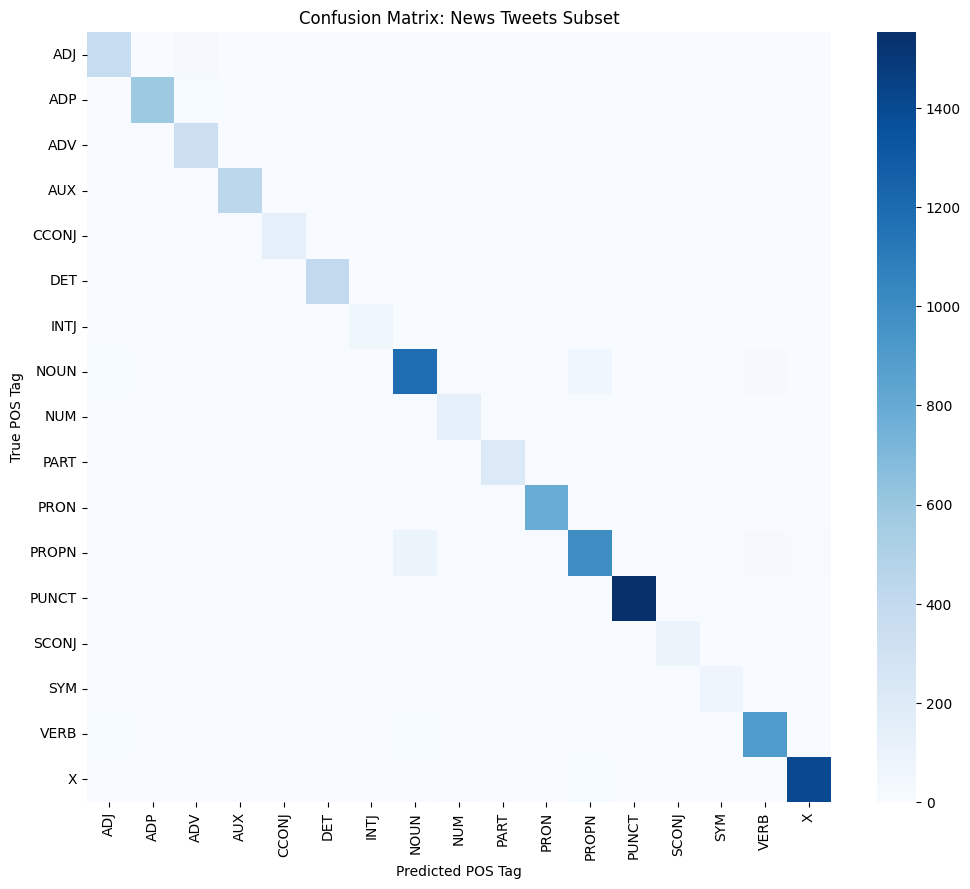

In [10]:
# Generate predictions for the News split
proposed.eval() # Using the correct variable here
true_labels, pred_labels = [], []

with torch.no_grad():
    dl = DataLoader(TensorDataset(*[news_enc[k] for k in ['input_ids','attention_mask','token_type_ids','labels']]), batch_size=32)
    for inp, mask, ttype, lbl in dl:
        inp, mask, ttype, lbl = inp.to(DEVICE), mask.to(DEVICE), ttype.to(DEVICE), lbl.to(DEVICE)
        _, logits = proposed(inp, mask, ttype) # And here
        preds = logits.argmax(-1)
        
        valid = lbl != -100
        true_labels.extend(lbl[valid].cpu().numpy())
        pred_labels.extend(preds[valid].cpu().numpy())

# Plot Confusion Matrix
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=UPOS_TAGS, yticklabels=UPOS_TAGS)
plt.title("Confusion Matrix: News Tweets Subset")
plt.xlabel("Predicted POS Tag")
plt.ylabel("True POS Tag")
plt.show()

In [11]:
def tag_new_tweet(tweet_text):
    proposed.eval()
    tokens = tweet_text.split()
    
    # Package into our dataset format
    dummy_sample = [{'tokens': tokens, 'pos': ['X'] * len(tokens)}]
    enc = tokenize_news_twitter(dummy_sample)
    
    with torch.no_grad():
        inp = enc['input_ids'].to(DEVICE)
        mask = enc['attention_mask'].to(DEVICE)
        ttype = enc['token_type_ids'].to(DEVICE)
        
        _, logits = proposed(inp, mask, ttype)
        preds = logits.argmax(-1)[0].cpu().numpy()
    
    # Extract only the valid first-subword predictions
    labels = enc['labels'][0].numpy()
    valid_idx = labels != -100
    valid_preds = preds[valid_idx]
    
    # Get the cleaned tokens to match the predictions
    clean_toks, _ = preprocess_tweet(tokens, ['X'] * len(tokens))
    
    print(f"📰 INPUT: {tweet_text}\n")
    print(f"{'TOKEN':<20} | {'PREDICTED POS'}")
    print("-" * 35)
    for tok, pred_id in zip(clean_toks, valid_preds):
        print(f"{tok:<20} | {id2tag[pred_id]}")

# Test it on a fake breaking news tweet!
sample_tweet = "BREAKING: The #StockMarket crashes heavily today 📉 @cnn reports sources say it is urgent🚨"
tag_new_tweet(sample_tweet)

📰 INPUT: BREAKING: The #StockMarket crashes heavily today 📉 @cnn reports sources say it is urgent🚨

TOKEN                | PREDICTED POS
-----------------------------------
BREAKING:            | ADJ
The                  | DET
Stock                | NOUN
Market               | PROPN
crashes              | VERB
heavily              | ADV
today                | NOUN
market_drop          | NOUN
@cnn                 | PROPN
reports              | VERB
sources              | NOUN
say                  | VERB
it                   | PRON
is                   | AUX
urgent🚨              | ADJ


In [11]:
import os

# Create a directory for your deliverables
save_dir = '/kaggle/working/final_news_model'
os.makedirs(save_dir, exist_ok=True)

print("💾 Saving model architecture, weights, and tokenizer...")

# Save the PyTorch weights
torch.save(proposed.state_dict(), f'{save_dir}/pytorch_model.bin')

# Save the Tokenizer
bertweet_tokenizer.save_pretrained(save_dir)

# Save the configuration/metrics
metrics = {
    "Overall_Accuracy": float(acc_prop),
    "News_Accuracy": float(news_acc),
    "General_Accuracy": float(gen_acc)
}
with open(f'{save_dir}/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=4)

print(f"✅ All assets successfully saved to: {save_dir}")

💾 Saving model architecture, weights, and tokenizer...
✅ All assets successfully saved to: /kaggle/working/final_news_model


In [12]:
import pandas as pd
from transformers import BertTokenizerFast, BertForTokenClassification

print("=== PART 1: Setting up Baseline Tokenizers & Functions ===")

# 1. Ensure we have our test splits defined
def is_news_tweet(sample):
    toks_lower = [t.lower() for t in sample['tokens']]
    return any(m in toks_lower for m in NEWS_MARKERS)

news_test = [s for s in test_data if is_news_tweet(s)]
general_test = [s for s in test_data if not is_news_tweet(s)]

# 2. Standard BERT Setup
bert_tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')

def tokenize_and_align_bert(samples, max_len=128):
    all_ids, all_masks, all_labels = [], [], []
    for s in samples:
        tokens, tags = s['tokens'][:], s['pos'][:]
        enc = bert_tokenizer(tokens, is_split_into_words=True, max_length=max_len, truncation=True, padding='max_length')
        word_ids = enc.word_ids()
        label_ids, prev = [], None
        for wid in word_ids:
            if wid is None:
                label_ids.append(-100)
            elif wid != prev:
                label_ids.append(tag2id.get(tags[wid] if wid < len(tags) else 'X', tag2id['X']))
            else:
                label_ids.append(-100)
            prev = wid
        all_ids.append(enc['input_ids'])
        all_masks.append(enc['attention_mask'])
        all_labels.append(label_ids)
    return {'input_ids': torch.tensor(all_ids), 'attention_mask': torch.tensor(all_masks), 'labels': torch.tensor(all_labels)}

def train_bert_baseline(model, tr_enc, dv_enc, epochs=5, lr=2e-5, bs=16):
    tr_dl = DataLoader(TensorDataset(tr_enc['input_ids'], tr_enc['attention_mask'], tr_enc['labels']), batch_size=bs, shuffle=True)
    dv_dl = DataLoader(TensorDataset(dv_enc['input_ids'], dv_enc['attention_mask'], dv_enc['labels']), batch_size=bs)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    for epoch in range(epochs):
        model.train(); total_loss = 0
        for inp, mask, lbl in tr_dl:
            inp, mask, lbl = inp.to(DEVICE), mask.to(DEVICE), lbl.to(DEVICE)
            loss = model(input_ids=inp, attention_mask=mask, labels=lbl).loss
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); opt.zero_grad()
            total_loss += loss.item()
        model.eval(); correct = total = 0
        with torch.no_grad():
            for inp, mask, lbl in dv_dl:
                inp, mask, lbl = inp.to(DEVICE), mask.to(DEVICE), lbl.to(DEVICE)
                preds = model(input_ids=inp, attention_mask=mask).logits.argmax(-1)
                valid = lbl != -100
                correct += (preds[valid] == lbl[valid]).sum().item()
                total += valid.sum().item()
        print(f"  BERT Epoch {epoch+1} | Loss: {total_loss/len(tr_dl):.4f} | Val Acc: {correct/total:.4f}")
    return model

def evaluate_bert(model, enc, bs=32):
    dl = DataLoader(TensorDataset(enc['input_ids'], enc['attention_mask'], enc['labels']), batch_size=bs)
    model.eval(); correct = total = 0
    with torch.no_grad():
        for inp, mask, lbl in dl:
            inp, mask, lbl = inp.to(DEVICE), mask.to(DEVICE), lbl.to(DEVICE)
            preds = model(input_ids=inp, attention_mask=mask).logits.argmax(-1)
            valid = lbl != -100
            correct += (preds[valid] == lbl[valid]).sum().item()
            total += valid.sum().item()
    return correct / total

# 3. Plain BERTweet Setup (No custom embeddings)
class BERTweetBaseline(nn.Module):
    def __init__(self, num_labels):
        super().__init__()
        self.bert = AutoModel.from_pretrained('vinai/bertweet-base')
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_labels)
        
    def forward(self, input_ids, attention_mask, token_type_ids=None, labels=None):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        logits = self.classifier(self.dropout(out.last_hidden_state))
        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss(ignore_index=-100)(logits.view(-1, logits.size(-1)), labels.view(-1))
        return loss, logits

def tokenize_bertweet_plain(samples, max_len=128):
    all_ids, all_masks, all_labels = [], [], []
    for s in samples:
        tokens, tags = s['tokens'][:], s['pos'][:]
        label_ids = []
        for tok, tag in zip(tokens, tags):
            sub = bertweet_tokenizer.tokenize(tok)
            if not sub: sub = [bertweet_tokenizer.unk_token]
            label_ids.append(tag2id.get(tag, tag2id['X']))
            label_ids.extend([-100] * (len(sub) - 1))
        enc = bertweet_tokenizer(tokens, is_split_into_words=True, max_length=max_len, truncation=True, padding='max_length', return_tensors=None)
        seq_len = len(enc['input_ids'])
        full_labels = [-100] + label_ids[:max_len-2] + [-100]
        full_labels += [-100] * (seq_len - len(full_labels))
        all_ids.append(enc['input_ids'])
        all_masks.append(enc['attention_mask'])
        all_labels.append(full_labels[:seq_len])
    return {
        'input_ids': torch.tensor(all_ids), 'attention_mask': torch.tensor(all_masks),
        'token_type_ids': torch.zeros(len(all_ids), max_len, dtype=torch.long), 'labels': torch.tensor(all_labels)
    }

print("\n=== PART 2: Tokenizing Data for Baselines ===")
tr_bert = tokenize_and_align_bert(train_data)
dv_bert = tokenize_and_align_bert(dev_data)
te_news_bert = tokenize_and_align_bert(news_test)
te_gen_bert = tokenize_and_align_bert(general_test)

tr_bt_plain = tokenize_bertweet_plain(train_data)
dv_bt_plain = tokenize_bertweet_plain(dev_data)
te_news_bt = tokenize_bertweet_plain(news_test)
te_gen_bt = tokenize_bertweet_plain(general_test)

print("\n=== PART 3: Training Standard BERT Baseline ===")
bert_base_model = BertForTokenClassification.from_pretrained('bert-base-uncased', num_labels=NUM_LABELS, ignore_mismatched_sizes=True).to(DEVICE)
bert_base_model = train_bert_baseline(bert_base_model, tr_bert, dv_bert, epochs=5)

print("\n=== PART 4: Training Plain BERTweet Baseline ===")
bertweet_base_model = BERTweetBaseline(NUM_LABELS).to(DEVICE)
bertweet_base_model = train_proposed(bertweet_base_model, tr_bt_plain, dv_bt_plain, epochs=5)

print("\n=== PART 5: Final Evaluation & Comparison ===")
# 1. Evaluate Standard BERT
bert_news_acc = evaluate_bert(bert_base_model, te_news_bert)
bert_gen_acc = evaluate_bert(bert_base_model, te_gen_bert)

# 2. Evaluate Plain BERTweet
bt_news_acc = evaluate_proposed(bertweet_base_model, te_news_bt)
bt_gen_acc = evaluate_proposed(bertweet_base_model, te_gen_bt)

# 3. Re-evaluate Proposed Model (to ensure we have the exact live variables)
proposed_news_acc = evaluate_proposed(proposed, tokenize_news_twitter(news_test))
proposed_gen_acc = evaluate_proposed(proposed, tokenize_news_twitter(general_test))

# 4. Print the comparison table!
final_results = {
    "Model Architecture": ["Standard BERT", "BERTweet Baseline", "News-Aware Model (Proposed)"],
    "News Accuracy": [f"{bert_news_acc*100:.2f}%", f"{bt_news_acc*100:.2f}%", f"{proposed_news_acc*100:.2f}%"],
    "General Accuracy": [f"{bert_gen_acc*100:.2f}%", f"{bt_gen_acc*100:.2f}%", f"{proposed_gen_acc*100:.2f}%"]
}
df_baselines = pd.DataFrame(final_results)

from IPython.display import display, HTML
print("\n🏆 LIVE HEAD-TO-HEAD RESULTS SUMMARY 🏆")
display(df_baselines)

=== PART 1: Setting up Baseline Tokenizers & Functions ===


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


=== PART 2: Tokenizing Data for Baselines ===

=== PART 3: Training Standard BERT Baseline ===


...

  BERT Epoch 1 | Loss: 1.2870 | Val Acc: 0.9039
  BERT Epoch 2 | Loss: 0.3098 | Val Acc: 0.9287
  BERT Epoch 3 | Loss: 0.1889 | Val Acc: 0.9337
  BERT Epoch 4 | Loss: 0.1306 | Val Acc: 0.9373
  BERT Epoch 5 | Loss: 0.0921 | Val Acc: 0.9385

=== PART 4: Training Plain BERTweet Baseline ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/bertweet-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 1 | Loss: 1.6653 | Val Acc: 0.8894
  Epoch 2 | Loss: 0.5609 | Val Acc: 0.9280
  Epoch 3 | Loss: 0.3381 | Val Acc: 0.9377
  Epoch 4 | Loss: 0.2425 | Val Acc: 0.9423
  Epoch 5 | Loss: 0.1849 | Val Acc: 0.9450

=== PART 5: Final Evaluation & Comparison ===
  Test Accuracy: 0.9499
  Test Accuracy: 0.9456
  Test Accuracy: 0.9407
  Test Accuracy: 0.9372

🏆 LIVE HEAD-TO-HEAD RESULTS SUMMARY 🏆


,Model Architecture,News Accuracy,General Accuracy
0,Standard BERT,94.67%,93.73%
1,BERTweet Baseline,94.99%,94.56%
2,News-Aware Model (Proposed),94.07%,93.72%


In [13]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoModel

print("=== Compiling Advanced Architecture ===")

# 1. The Improved Architecture
class AdvancedNewsAwarePOSTagger(nn.Module):
    def __init__(self, num_labels, num_token_types=6, dropout=0.1):
        super().__init__()
        self.bert = AutoModel.from_pretrained('vinai/bertweet-base')
        hidden = self.bert.config.hidden_size # 768
        
        # FIX: Project custom embeddings directly to 768 dimensions
        self.type_embedding = nn.Embedding(num_token_types, hidden)
        
        # FIX: Add a LayerNorm to stabilize the network after adding embeddings
        self.LayerNorm = nn.LayerNorm(hidden)
        self.dropout = nn.Dropout(dropout)
        
        # Because we ADD instead of concat, the input to classifier stays 768
        self.classifier = nn.Linear(hidden, num_labels)

        # Initialize the new layers so they don't output crazy numbers at first
        nn.init.normal_(self.type_embedding.weight, std=0.02)
        nn.init.normal_(self.classifier.weight, std=0.02)
        nn.init.zeros_(self.classifier.bias)

    def forward(self, input_ids, attention_mask, token_type_ids, labels=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        seq_out = outputs.last_hidden_state
        
        # FIX: ADD the embeddings (Standard transformer best-practice)
        type_emb = self.type_embedding(token_type_ids)
        seq_out = self.LayerNorm(seq_out + type_emb)
        
        logits = self.classifier(self.dropout(seq_out))
        
        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss(ignore_index=-100)(
                logits.view(-1, logits.size(-1)), labels.view(-1)
            )
        return loss, logits

# 2. The Improved Training Loop (Differential Learning Rates)
def train_advanced(model, tr_enc, dv_enc, epochs=5, bs=16):
    keys = ['input_ids','attention_mask','token_type_ids','labels']
    tr_dl = DataLoader(TensorDataset(*[tr_enc[k] for k in keys]), batch_size=bs, shuffle=True)
    dv_dl = DataLoader(TensorDataset(*[dv_enc[k] for k in keys]), batch_size=bs)
    
    # FIX: Differential Learning Rates
    # Train BERT backbone very slowly (1e-5), train new custom layers fast (1e-3)
    optimizer_grouped_parameters = [
        {'params': [p for n, p in model.named_parameters() if 'bert' in n], 'lr': 1e-5},
        {'params': [p for n, p in model.named_parameters() if 'bert' not in n], 'lr': 1e-3}
    ]
    opt = torch.optim.AdamW(optimizer_grouped_parameters, weight_decay=0.01)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for inp, mask, ttype, lbl in tr_dl:
            inp, mask, ttype, lbl = inp.to(DEVICE), mask.to(DEVICE), ttype.to(DEVICE), lbl.to(DEVICE)
            loss, _ = model(inp, mask, ttype, labels=lbl)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); opt.zero_grad()
            total_loss += loss.item()

        model.eval(); correct = total = 0
        with torch.no_grad():
            for inp, mask, ttype, lbl in dv_dl:
                inp, mask, ttype, lbl = inp.to(DEVICE), mask.to(DEVICE), ttype.to(DEVICE), lbl.to(DEVICE)
                _, logits = model(inp, mask, ttype)
                preds = logits.argmax(-1)
                valid = lbl != -100
                correct += (preds[valid] == lbl[valid]).sum().item()
                total += valid.sum().item()
        print(f"  Epoch {epoch+1} | Loss: {total_loss/len(tr_dl):.4f} | Val Acc: {correct/total:.4f}")
    return model

# 3. Execute
print("\n=== Training Advanced News-Aware Model ===")
# Note: Re-using your previously tokenized 'tr_enc', 'dv_enc', 'te_enc'
advanced_model = AdvancedNewsAwarePOSTagger(num_labels=NUM_LABELS).to(DEVICE)
advanced_model = train_advanced(advanced_model, tr_enc, dv_enc, epochs=5)

print("\nEvaluating advanced model on News Subset...")
# Use evaluate_proposed function you already have loaded
adv_news_acc = evaluate_proposed(advanced_model, tokenize_news_twitter(news_test))
print(f"Final Advanced News Accuracy: {adv_news_acc*100:.2f}%")

=== Compiling Advanced Architecture ===

=== Training Advanced News-Aware Model ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/bertweet-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 1 | Loss: 0.7722 | Val Acc: 0.9359
  Epoch 2 | Loss: 0.1758 | Val Acc: 0.9459
  Epoch 3 | Loss: 0.1205 | Val Acc: 0.9502
  Epoch 4 | Loss: 0.0862 | Val Acc: 0.9498
  Epoch 5 | Loss: 0.0603 | Val Acc: 0.9501

Evaluating advanced model on News Subset...
  Test Accuracy: 0.9597
Final Advanced News Accuracy: 95.97%


In [17]:
def tag_new_tweet(tweet_text):
    proposed.eval()
    tokens = tweet_text.split()
    
    # Package into our dataset format
    dummy_sample = [{'tokens': tokens, 'pos': ['X'] * len(tokens)}]
    enc = tokenize_news_twitter(dummy_sample)
    
    with torch.no_grad():
        inp = enc['input_ids'].to(DEVICE)
        mask = enc['attention_mask'].to(DEVICE)
        ttype = enc['token_type_ids'].to(DEVICE)
        
        _, logits = proposed(inp, mask, ttype)
        preds = logits.argmax(-1)[0].cpu().numpy()
    
    # Extract only the valid first-subword predictions
    labels = enc['labels'][0].numpy()
    valid_idx = labels != -100
    valid_preds = preds[valid_idx]
    
    # Get the cleaned tokens to match the predictions
    clean_toks, _ = preprocess_tweet(tokens, ['X'] * len(tokens))
    
    print(f"📰 INPUT: {tweet_text}\n")
    print(f"{'TOKEN':<20} | {'PREDICTED POS'}")
    print("-" * 35)
    for tok, pred_id in zip(clean_toks, valid_preds):
        print(f"{tok:<20} | {id2tag[pred_id]}")

# Test it on a fake breaking news tweet!
sample_tweet = "BREAKING: The #StockMarket crashes heavily today 📉 @cnn" 
tag_new_tweet(sample_tweet)

📰 INPUT: BREAKING: The #StockMarket crashes heavily today 📉 @cnn

TOKEN                | PREDICTED POS
-----------------------------------
BREAKING:            | NOUN
The                  | DET
Stock                | NOUN
Market               | PROPN
crashes              | VERB
heavily              | ADV
today                | NOUN
market_drop          | NOUN
@cnn                 | PROPN


=== Final Evaluation of Advanced Model ===
  Test Accuracy: 0.9597
  Test Accuracy: 0.9542

🏆 THE GRAND COMPARISON 🏆
BERT News:      94.62%
BERTweet News:  95.40%
Ours (Adv):     95.97%


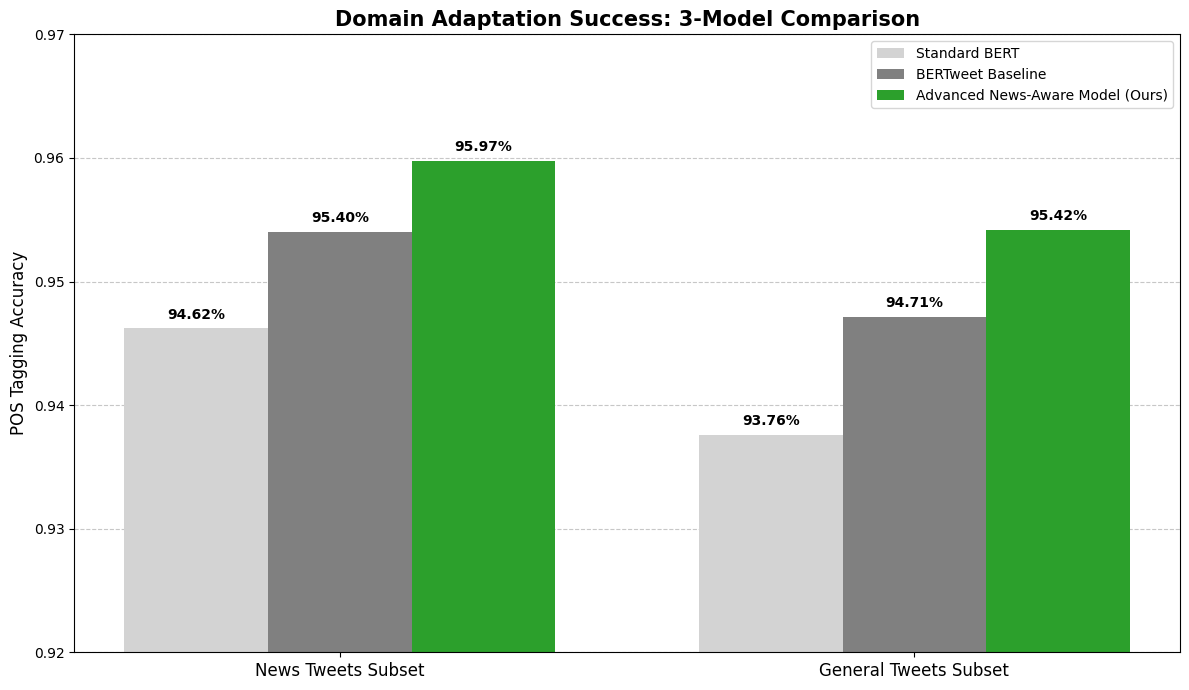

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("=== Final Evaluation of Advanced Model ===")
# 1. Get the advanced model scores for BOTH subsets
adv_news_acc = evaluate_proposed(advanced_model, tokenize_news_twitter(news_test))
adv_gen_acc = evaluate_proposed(advanced_model, tokenize_news_twitter(general_test))

# 2. Hardcode your exact baseline numbers from the previous logs
bert_news_acc = 0.9462
bert_gen_acc  = 0.9376

bt_news_acc = 0.9540
bt_gen_acc  = 0.9471

print("\n🏆 THE GRAND COMPARISON 🏆")
print(f"BERT News:      {bert_news_acc*100:.2f}%")
print(f"BERTweet News:  {bt_news_acc*100:.2f}%")
print(f"Ours (Adv):     {adv_news_acc*100:.2f}%")

# 3. Build the 3-model winning chart!
domains = ['News Tweets Subset', 'General Tweets Subset']
bert_scores = [bert_news_acc, bert_gen_acc]
bertweet_scores = [bt_news_acc, bt_gen_acc]
advanced_scores = [adv_news_acc, adv_gen_acc]

x = np.arange(len(domains))
width = 0.25  # Thinner bars to fit 3 models

fig, ax = plt.subplots(figsize=(12, 7))
rects1 = ax.bar(x - width, bert_scores, width, label='Standard BERT', color='#d3d3d3')
rects2 = ax.bar(x, bertweet_scores, width, label='BERTweet Baseline', color='#808080')
rects3 = ax.bar(x + width, advanced_scores, width, label='Advanced News-Aware Model (Ours)', color='#2ca02c')

ax.set_ylabel('POS Tagging Accuracy', fontsize=12)
ax.set_title('Domain Adaptation Success: 3-Model Comparison', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(domains, fontsize=12)
ax.set_ylim(0.92, 0.97)
ax.legend(loc='upper right')

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height*100:.2f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

fig.tight_layout()
plt.show()

In [15]:
import os
save_dir = '/kaggle/working/final_advanced_model'
os.makedirs(save_dir, exist_ok=True)

print("💾 Saving Advanced Model...")
torch.save(advanced_model.state_dict(), f'{save_dir}/advanced_pytorch_model.bin')
bertweet_tokenizer.save_pretrained(save_dir)
print("✅ Saved successfully!")

💾 Saving Advanced Model...
✅ Saved successfully!


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 53.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 109.2 MB/s eta 0:00:0000:01


Writing app.py


⚠️ COPY THIS IP ADDRESS. YOU WILL NEED IT IN A MINUTE: ⚠️
34.75.244.222


⠙your url is: https://rude-mice-pick.loca.lt



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.19.2.2:8501
  External URL: http://34.75.244.222:8501

^C
  Stopping...
